---

MD004 - Algoritmos de Clustering (A: 8/01/2026) (B: 12/01/2026)

## Ejemplo clustering jerárquico

**¿Que es el clustering jerárquico?** <br><br>

El clustering jerárquico es un método de aprendizaje no supervisado que agrupa datos basándose en la similitud o distancia entre ellos. 
A diferencia de otros métodos (como K-Means), aquí no necesitas especificar el número de clusters ($k$) de antemano, ya que el algoritmo construye una jerarquía completa de agrupaciones.<br><br>

**Existen enfoques principales de agrupación (hay 2):**
- Aglomerativo (Bottom-Up): cada dato empieza siendo su propio clúster. En cada paso, se fusionan los dos clústers más cercanos hasta que solo queda uno que engloba a todos los datos.
- Divisivo (Top-Down): los datos empiezan en un solo clúster gigante y se van dividiendo recursivamente hasta que cada dato es un clúster individual.
<br><br>

**¿Cómo se mide la "cercanía"?**
- Métrica de Distancia: primero, el algoritmo necesita saber cuán lejos está un punto $A$ de un punto $B$ (con: distancia Euclidiana, distancia manhattan, etc.)
<br><br>

¿Cómo se mide la distancia entre grupos?
- Criterio de Enlace o "Linkage": 
    - Ward: intenta minimizar la varianza dentro de los clústers. Al fusionar dos grupos, calcula cuánto aumentaría el "error" o la dispersión interna. Este valor crece muy rápido (cuadráticamente), por eso ves valores altos en el eje Y (como 30 o 100).
    - Complete Linkage: distancia entre dos clústers es la distancia entre sus dos puntos más lejanos
    - Single Linkage: distancia entre dos clústers es la distancia entre sus dos puntos más cercanos.
    - Average Linkage: calcula la distancia promedio entre todos los puntos de un clúster contra todos los del otro

<br>

Para representar las distáncias se utiliza un ``dendograma``, es decir, una estructura en forma de árbol que relaciona los datos. <br><br>

<div align="center">
    <div align="center">
        <div style="display:flex; justify-content:center; gap:16px; flex-wrap:wrap;">
            <img src="https://i0.wp.com/spotintelligence.com/wp-content/uploads/2023/09/hierarchical-clustering-results.png?resize=640%2C480&ssl=1" alt="Resultados clustering jerárquico" style="width:512px; height:auto;" />
            <img src="https://i0.wp.com/spotintelligence.com/wp-content/uploads/2023/09/hierarchical-clustering-dendogram.png?resize=640%2C480&ssl=1" alt="Guía clustering jerárquico" style="width:512px; height:auto;" />
        </div>
    </div>
</div>

<br><br>

**¿Que se debe hacer en este notebook?** <br><br>

Teneis que hacer import del csv ``fish_data.csv``, estudiar las variables/hacer un EDA y finalmente utilizar la librería ``scipy.cluster`` para hacer los clusters y visualizarlos

<br><br>

**Dataset:**
- [Ver el dataset en Kaggle — Fish Species (weight & height)](https://www.kaggle.com/datasets/taweilo/fish-species-sampling-weight-and-height-data?resource=download)

<br><br>

---


### **0. Imports y carga de datos**

In [4]:
import pandas as pd # Librería Pandas, es muy útil para el manejo de datos en ML
import numpy as np # Librería Numpy, se usa para operaciones matemáticas más eficientes

# Librería Scipy
from scipy.cluster import hierarchy # Utilizada para calcular la matriz de enlaces (linkage) y visualizar el dendrograma
from scipy.cluster.hierarchy import fcluster # Para conseguir los resultados del clustering
import scipy.stats as stats # Utilizada para tests estadísticos

# Librería Sklearn
from sklearn.preprocessing import StandardScaler # Para escalar los datos
from sklearn.metrics import silhouette_score # Para calcular el rendimiento del clustering
from sklearn.cluster import AgglomerativeClustering # Es la versión de Sklearn de "scipy.cluster"

# Librería MatplotLib
import matplotlib.pyplot as plt # Para personalizar los gráficos del dendrograma
import matplotlib.gridspec as gridspec # Para tener graficas compuestas

import plotly.express as px # Librería Plotly, para generar gráficos 3D (normalmente no la usaréis, solamente es para un ejemplo concreto ya que solamente tenemos 3 variables en el dataset)

import seaborn as sns # Librería Seaborn, para personalizar los gráficos


In [5]:
# Cargamos el dataset
dataset = pd.read_csv("fish_data.csv")

### **1. Estudio de los datos**

In [6]:
dataset.head()

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31


In [7]:
dataset.tail()

,species,length,weight,w_l_ratio
4075,Sillaginopsis panijus,30.56,6.12,0.20
4076,Sillaginopsis panijus,29.66,6.11,0.21
4077,Sillaginopsis panijus,32.81,6.25,0.19
4078,Sillaginopsis panijus,29.78,6.11,0.21
4079,Sillaginopsis panijus,31.62,6.14,0.19


Miramos el tamaño del dataset.

In [8]:
dataset.shape

(4080, 4)

In [9]:
dataset.dtypes

species       object
length       float64
weight       float64
w_l_ratio    float64
dtype: object

Miramos los distintos valores que hay en la variable ``species``.

In [10]:
species_values = dataset["species"].value_counts()
print(f"Cantidad de valores únicos de \"species\" \n\n{species_values}")

Cantidad de valores únicos de "species" 

species
Setipinna taty            480
Anabas testudineus        476
Pethia conchonius         475
Otolithoides biauritus    468
Polynemus paradiseus      458
Sillaginopsis panijus     455
Otolithoides pama         435
Puntius lateristriga      418
Coilia dussumieri         415
Name: count, dtype: int64


Se puede ver que no hay *nulls* en la columna species ya que no aparece ninguna categoria llamada "null". <br>
Si miramos cuantos valores distintos hay, confirmamos que la tabla anterior muestra que no hay nulls correctamente.

In [11]:
species_values.sum() # Sumamos los valores de cada fila de la tabla

np.int64(4080)

Vamos a mirar si hay *nulls* en las otras columnas.

In [12]:
# Recorremos todas las columnas del dataset
for col in dataset.columns:
    null_counts: int = (dataset[col] # Miramos una columna concretamente
          .isnull() # Miramos si el valor es null (devuelve True o False)
          .sum() # Sumamos los valores bool (True = 1 y False = 0), si nos da 0 quiere decir que no se ha encontrado ningún valor True
        ) 
    
    print(f"La columna \"{col}\" contiene {null_counts} nulls")
    
    # Nota: No hacen falta los intros en la función de null_counts, "print(dataset[col].isnull().sum())" esta bien, los he puesto para poder añadir comentarios. El paréntesis 
    # está puesto para poder escribir comentarios y separar la función en varias líneas, tampoco hace falta.

La columna "species" contiene 0 nulls
La columna "length" contiene 0 nulls
La columna "weight" contiene 0 nulls
La columna "w_l_ratio" contiene 0 nulls


In [13]:
print(f"La variable \'species\' tiene {len(dataset["species"].unique())} valores distintos")

La variable 'species' tiene 9 valores distintos


#### **1.1 EDA variables numéricas**

Vamos a estudiar el comportamiento de las variables numéricas. <br>
Primero vamos a separar las variables:
- ``length``
- ``weight``
- ``w_l_ratio``

In [14]:
dataset_numerical = dataset.select_dtypes(include=[np.number])
# dataset_numerical = dataset[["length", "weight", "w_l_ratio"]]

dataset_numerical.columns

Index(['length', 'weight', 'w_l_ratio'], dtype='object')

Para no tener que hacer un gráfico varias veces, vamos a hacer un bucle que muestre cada plot.

In [15]:
number_columns = 3
number_rows = len(dataset_numerical.columns) // number_columns

##### **1.1.1 Histogramas**

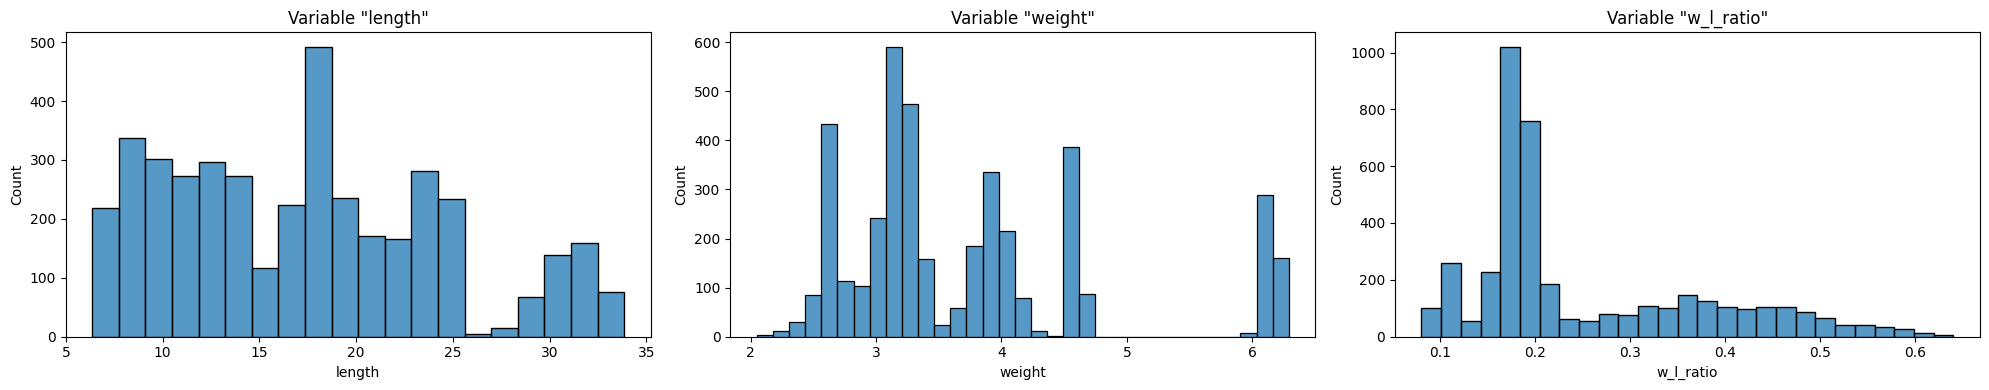

In [16]:
plt.figure(figsize=(20, 4 * number_rows)) # La imágen tiene que adaptarse a la cantidad de columnas

for i, col in enumerate(dataset_numerical.columns):
    # Creamos un subplot
    ax = plt.subplot(number_rows, number_columns, i + 1) 

    # Creamos el boxplot
    sns.histplot(data = dataset_numerical, x = col, ax = ax)
    ax.set_title(f"Variable \"{col}\"")

plt.tight_layout() # Para que se separen mejor las gráficas
plt.show()

##### **1.1.2 Boxplots**

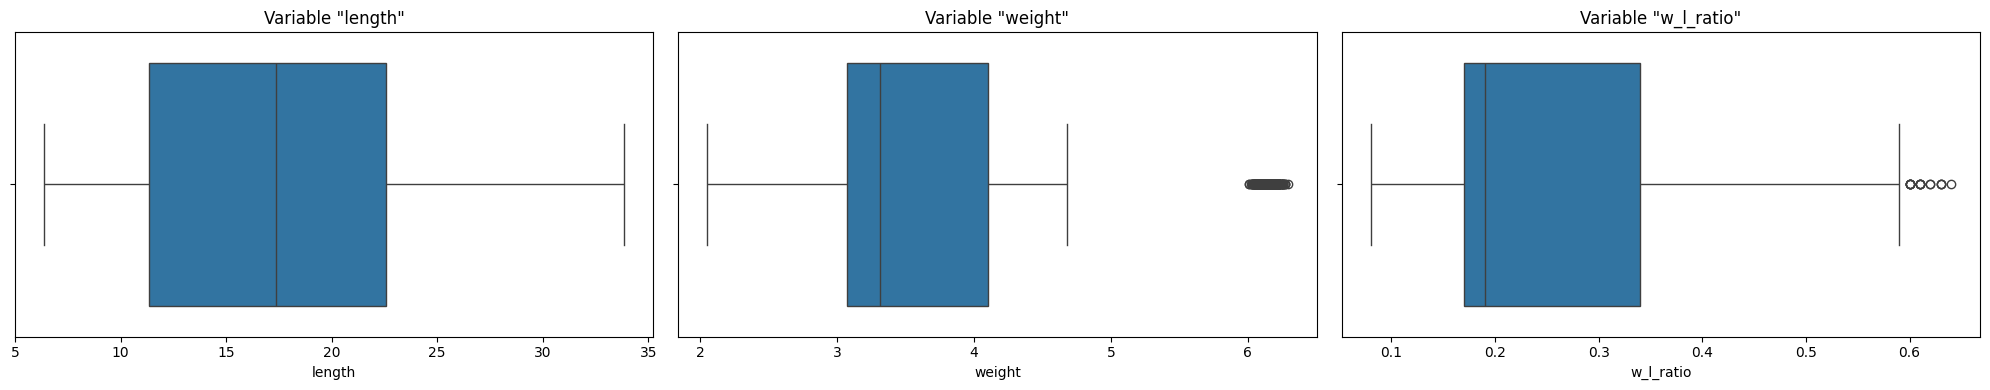

In [17]:
plt.figure(figsize=(20, 4 * number_rows)) # La imágen tiene que adaptarse a la cantidad de columnas

for i, col in enumerate(dataset_numerical.columns):
    # Creamos un subplot
    ax = plt.subplot(number_rows, number_columns, i + 1) 

    # Creamos el boxplot
    sns.boxplot(data = dataset_numerical, x = col, ax = ax)
    ax.set_title(f"Variable \"{col}\"")

plt.tight_layout()
plt.show()

##### **1.1.3 Histogramas i boxplots juntos**

/tmp/ipykernel_19662/3177202417.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


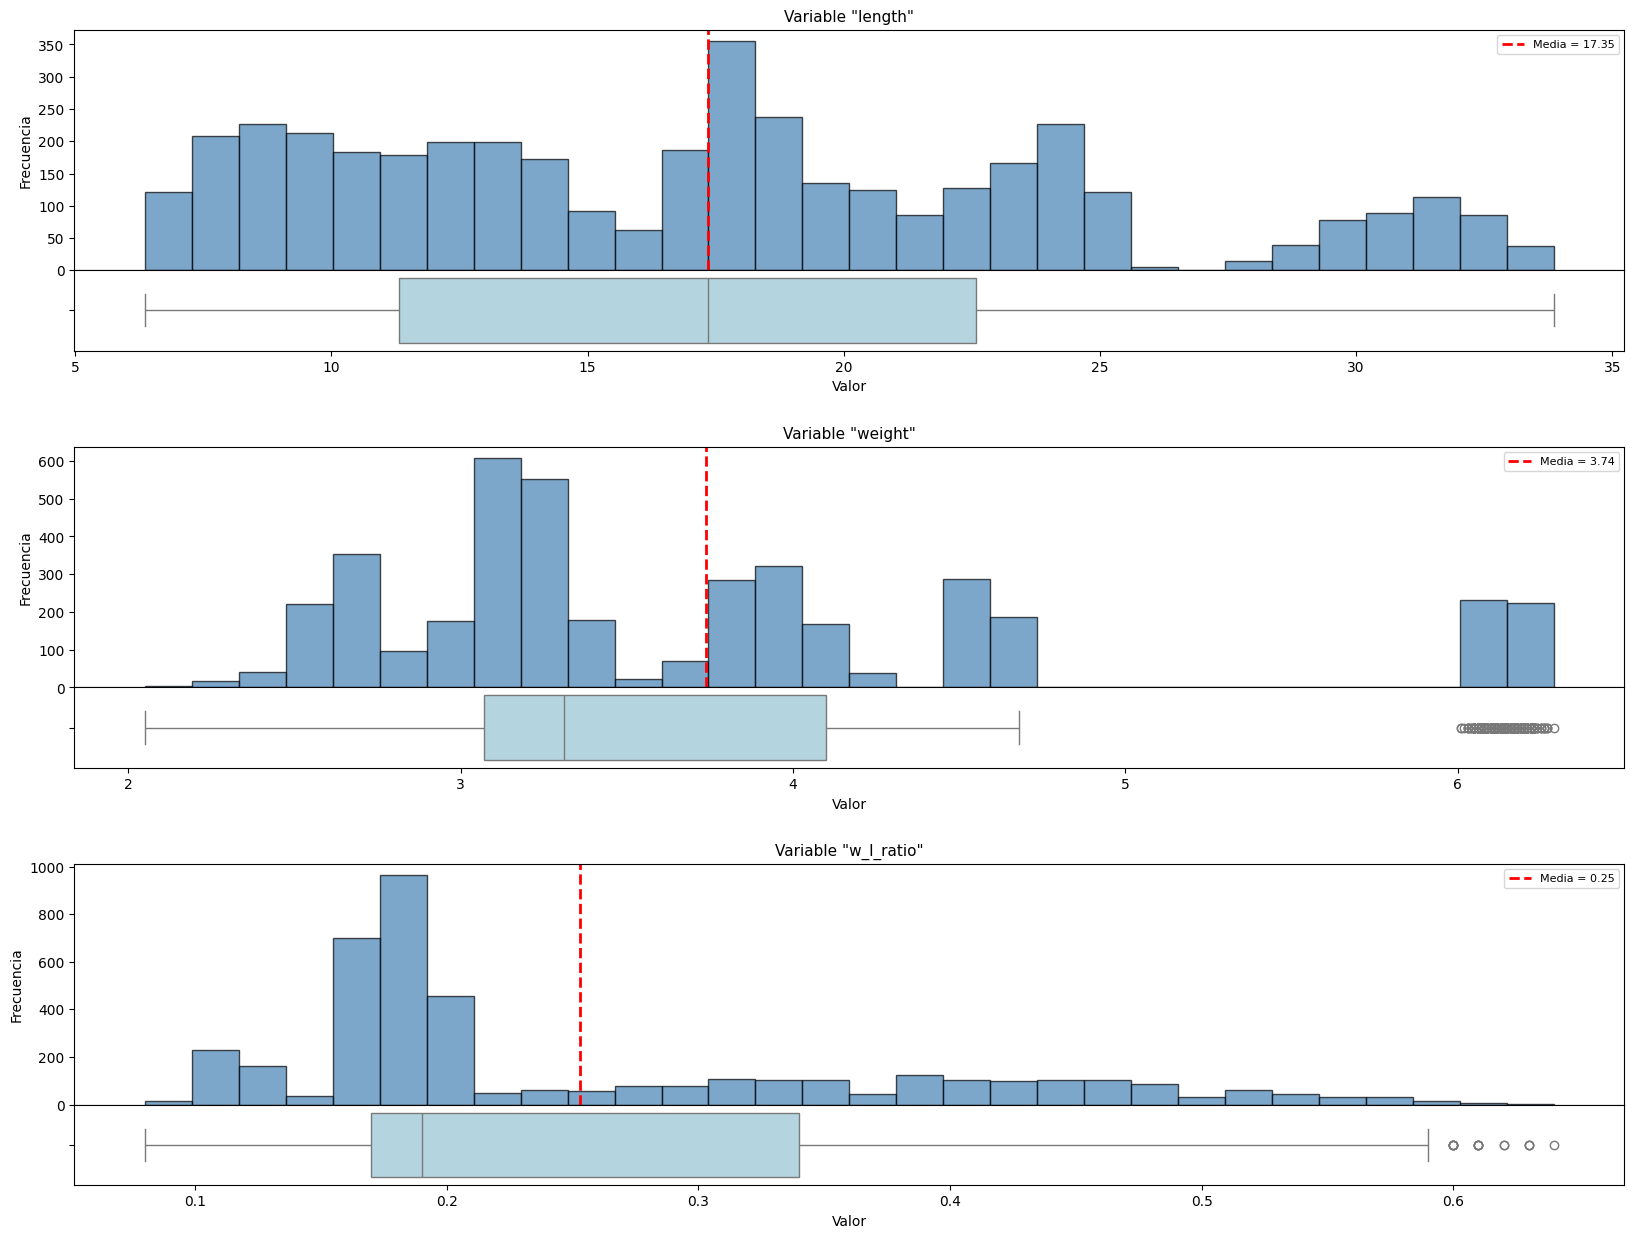

In [18]:
fig = plt.figure(figsize=(20, 5 * 3))
outer = gridspec.GridSpec(3, 1, wspace=0.2, hspace=0.3)

for i, col in enumerate(dataset_numerical.columns):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], height_ratios=[3, 1], hspace=0)

    data = dataset_numerical[col].dropna()
    mean_val = data.mean()

    # Histograma
    ax_hist = plt.Subplot(fig, inner[0])
    ax_hist.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Media = {mean_val:.2f}")
    ax_hist.set_title(f"Variable \"{col}\"", fontsize=11)
    ax_hist.set_ylabel("Frecuencia")
    ax_hist.set_xticks([])
    ax_hist.legend(loc='upper right', fontsize=8)
    fig.add_subplot(ax_hist)

    # Boxplot
    ax_box = plt.Subplot(fig, inner[1])
    sns.boxplot(x=data, ax=ax_box, orient="h", color="lightblue")
    ax_box.set_xlabel("Valor")
    fig.add_subplot(ax_box)

plt.tight_layout()
plt.show()

##### **1.1.4 Pairplot**

El pairplot nos permitirá mirar las relaciones entre las variables con scatter plots fácilmente, si añadimos el parámetro ``hue`` podremos asignar un color en función de un valor, en este caso vamos a pintar los puntos en función de la variable ``species`` de este modo podremos ver si a simple vista se pueden separar los puntos.

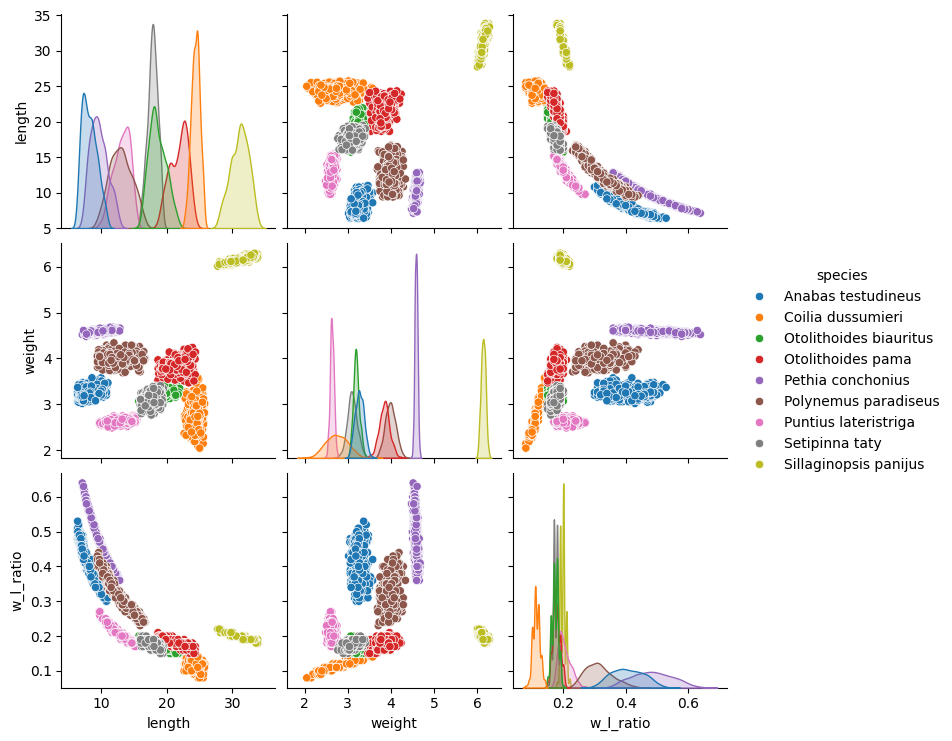

In [19]:
sns.pairplot(data=dataset, hue="species")
plt.show()

Parece que hay especies que se parecen entre sí en algunos valores, pero la mayoría de los datos sí que se diferencian correctamente en función de ``species``.

##### **1.1.5 Estudio correlaciones**
...
##### **1.1.6 Análisis de Componentes Principales (PCA)**
...
##### **1.1.7 Etc.**
...

##### **1.1.8 Extra: gráfico 3D**

Cómo tenemos solamente 3 variables podemos visualizarlas en un gráfico 3D para simplificar la interpretación.

In [20]:
fig = px.scatter_3d(dataset,
    x = "weight", y = "length", z = "w_l_ratio", # Ejes
    color='species', # Colores
    
    opacity=0.5, # Transparencia si los puntos se solapan
    width = 1000,
    height = 800,
)

fig.show()

#### **1.2 EDA variables categóricas**

Vamos a estudiar el comportamiento de las variables categóricas. <br>
Primero vamos a separar las variables:
- ``species``

In [21]:
dataset_categorical = dataset.select_dtypes(exclude=[np.number])
# dataset_categorical = dataset[["species"]]

dataset_categorical.columns

Index(['species'], dtype='object')

##### **1.2.1 Gráfico de cantidades**

/tmp/ipykernel_19662/1976367293.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




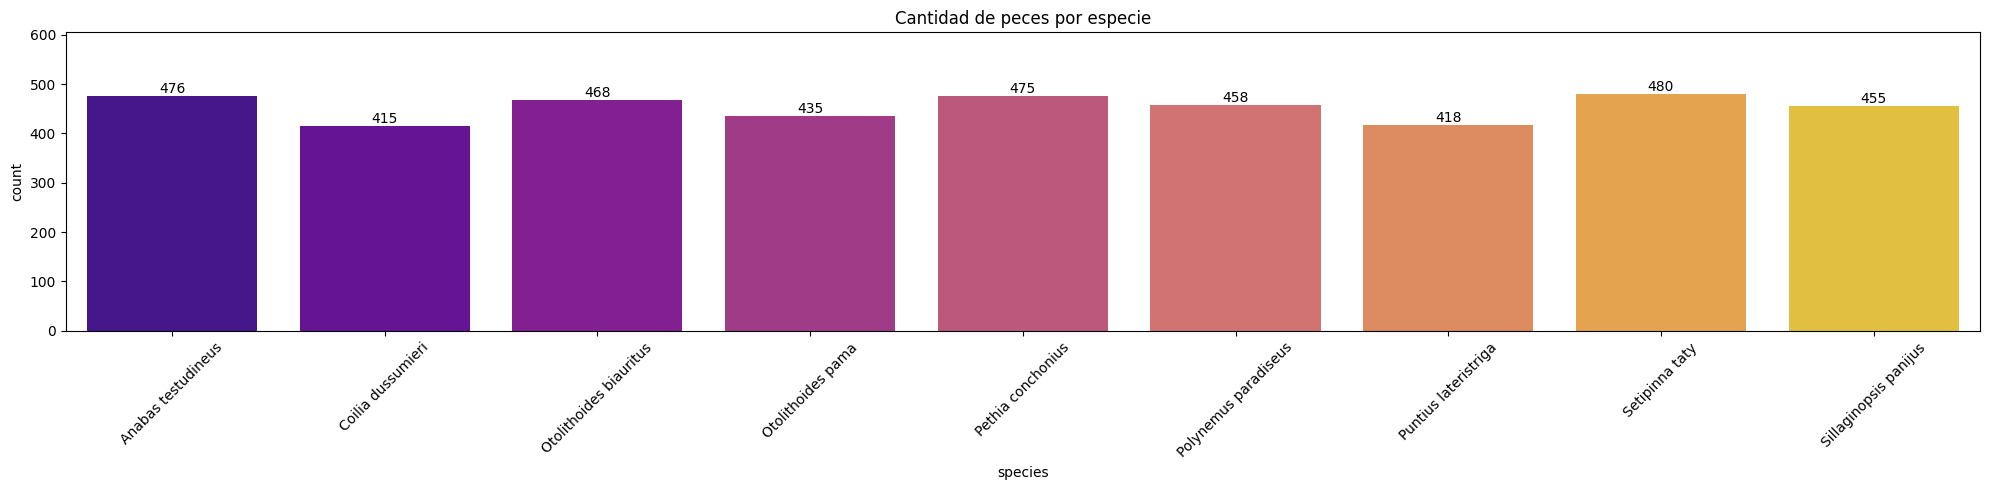

In [22]:
plt.figure(figsize=(20, 5 * number_rows)) # La imágen tiene que adaptarse a la cantidad de columnas

# Creamos el countplot
ax = sns.countplot(data = dataset, x = "species", palette = "plasma")

for cont in ax.containers:
    ax.bar_label(cont, )

# Dejamos más espacio en la parte superior del gráfico
plot_height = ax.get_ylim()[1]
ax.set_ylim(0, plot_height * 1.2)

ax.set_title(f"Cantidad de peces por especie")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

##### **1.2.2 Gráfico de barras**

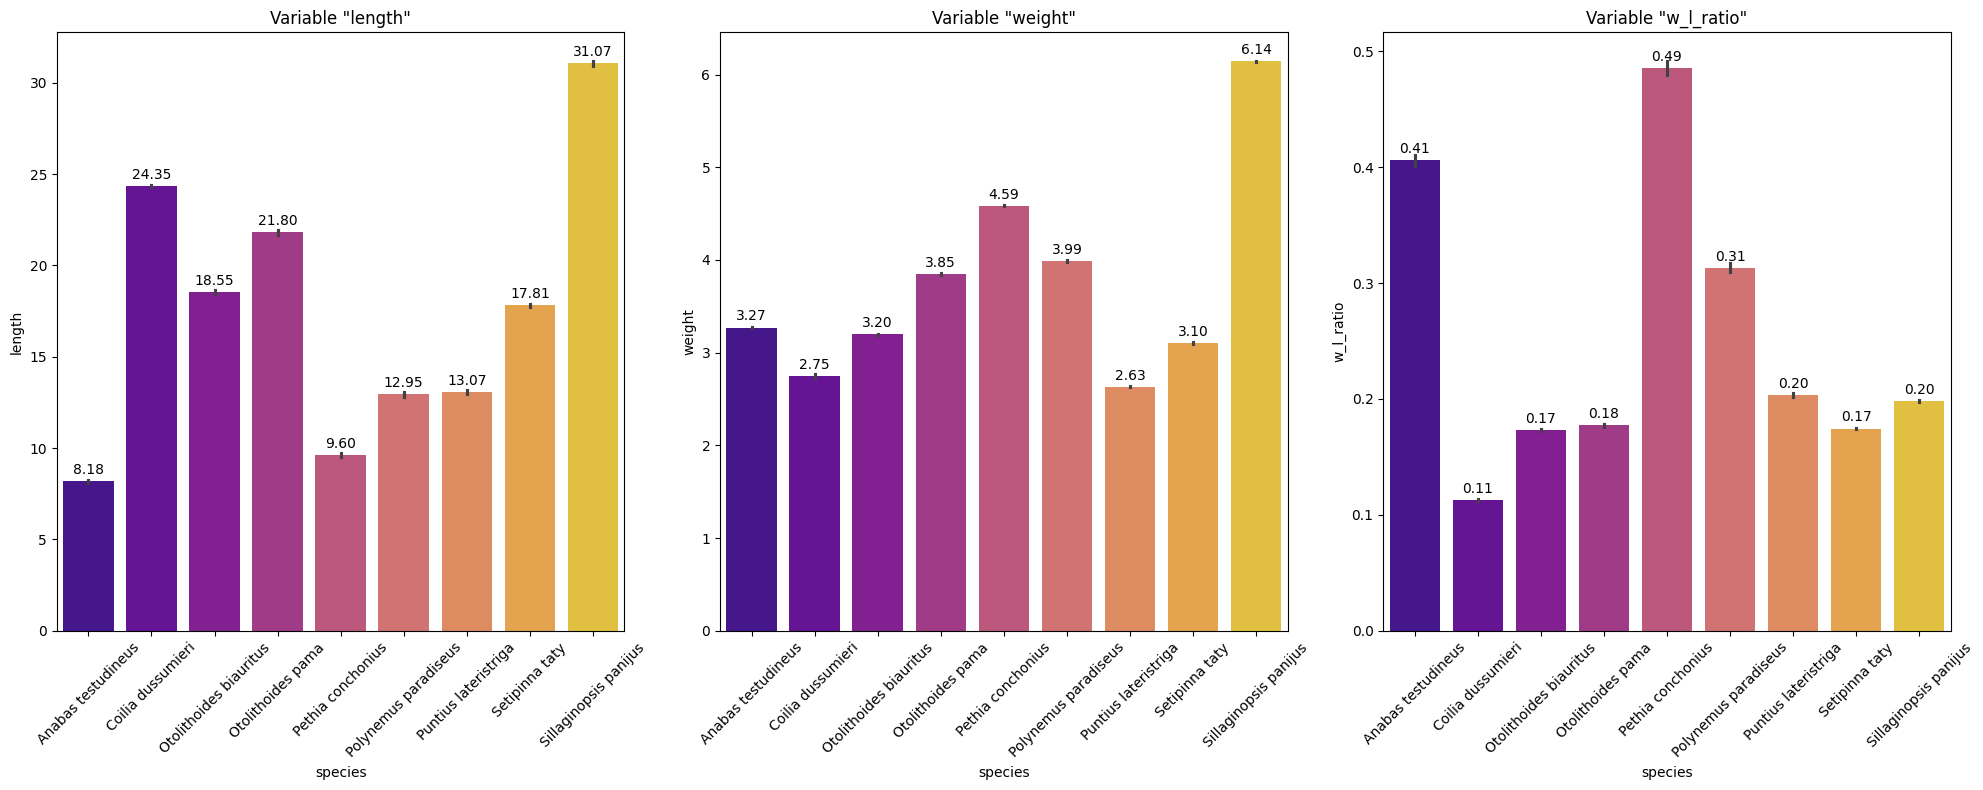

In [23]:
plt.figure(figsize=(20, 8 * number_rows)) # La imágen tiene que adaptarse a la cantidad de columnas

for i, col in enumerate(dataset_numerical.columns):
    # Creamos un subplot
    ax = plt.subplot(number_rows, number_columns, i + 1) 

    # Creamos el barplot
    sns.barplot(data = dataset, x = "species", y = col, ax = ax, 
                palette = "plasma", legend = False, hue = dataset["species"])

    # Mostramos el valor de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt = '%.2f', padding = 3)

    ax.set_title(f"Variable \"{col}\"")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

##### **1.2.3 Gráfico de violin**

/tmp/ipykernel_19662/2518637066.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_19662/2518637066.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_19662/2518637066.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




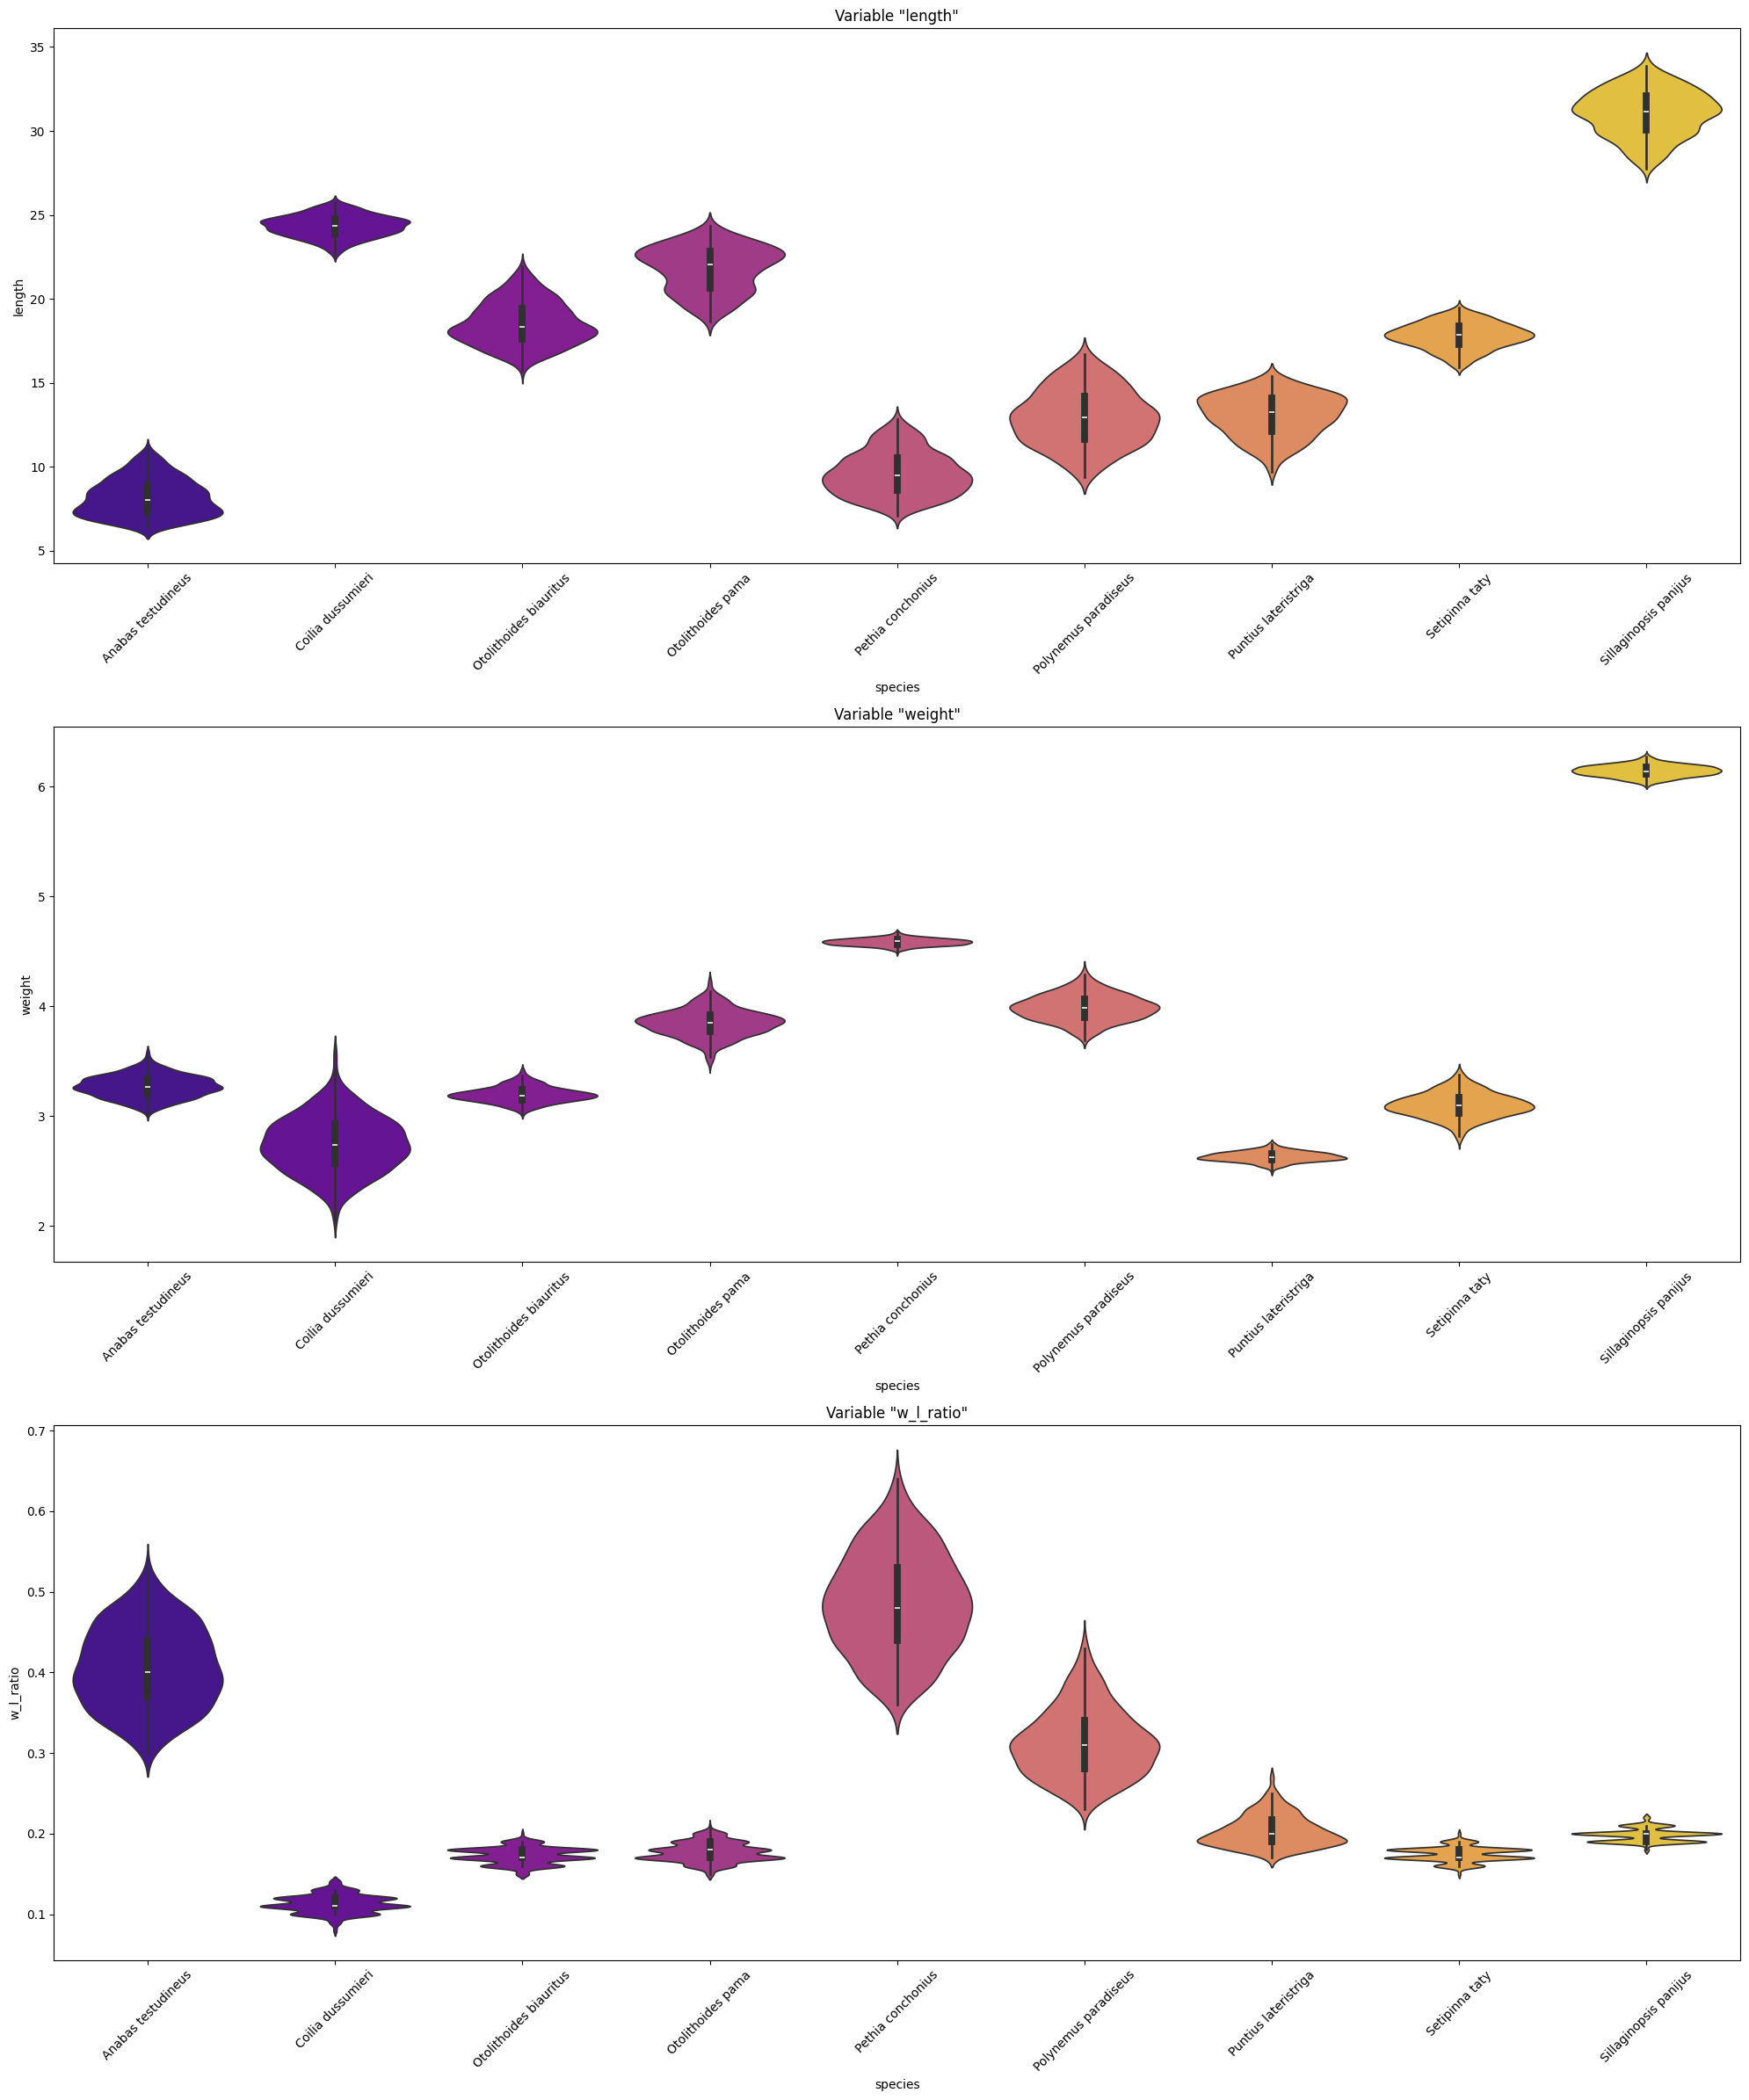

In [24]:
plt.figure(figsize=(20, 8 * 3)) # La imágen tiene que adaptarse a la cantidad de columnas

for i, col in enumerate(dataset_numerical.columns):
    # Creamos un subplot
    ax = plt.subplot(3, 1, i + 1) 

    # Creamos el boxplot
    sns.violinplot(data = dataset, x = "species", y = col, ax = ax, 
                   palette = "plasma")
    ax.set_title(f"Variable \"{col}\"")
    plt.xticks(rotation = 45)

plt.tight_layout() # Para que se separem mejor las gráficas
plt.show()

<br>

**¿Hace falta que el modelo tenga en cuenta la variable ``species``?** <br>

**Respuesta:** no, los modelos de clustering son <u>no supervisados</u>, es decir, aprenden los patrones sin necesidad de tener la respuesta/label de los datos. Para este tipo de problema vamos a mirar si el modelo de clustering puede diferenciar entre las clases sin el label y luego compararemos las agrupaciones del modelo respeto a los valores reales.

<br>

**¿Hace falta hacer train-test split de los datos?** <br>

**Respuesta:** estamos en un modelo que usa aprendizaje no supervisado, como no sabemos el "ground truth" no tenemos datos como contrastar los resultados. Tendremos que evaluar el rendimiento del modelo de otras maneras.

<br>

### **2. Modelo**

#### **2.1. Preparación del modelo**

Como los datos que tenemos son solamente los numéricos podemos usar directamente la variable que teníamos ``dataset_numerical``.

In [25]:
dataset.columns

Index(['species', 'length', 'weight', 'w_l_ratio'], dtype='object')

<br><br>

El agrupamiento jerárquico es extremadamente sensible a la escala de los datos. Para hacer la agrupación se están calculando distancias entre los datos, si tenemos datos en distintas unidades y no los estandarizamos pueden modificar el agrupamiento y empeorar los resultados.
<br>

**Por ejemplo:** imaginemos que tenemos las variables:
- ``longitud pez`` (en cm): 120 cm
- ``peso pez`` (en g): 2000g
- ``velocidad pez`` (en km/h): 7 km/h (velocidad crucero de un atún, a máxima velocidad puede llegar a los 70 km/h)

Los valores de ``peso pez`` tenderán a ser mayores a los de la ``velocidad pez`` (en valor absoluto y sin tener en cuenta las magnitudes de los datos). Al calcular la distancia entre los puntos de datos, algunos valores dominarán el cálculo, haciendo que el modelo no pueda diferenciar bien los datos.

<br>

Hay distintos tipos de normalizaciones:
- ``StandardScaler``: transforma los datos para que tengan una media de 0 y una desviación estándar de 1.
- ``MinMaxScaler``: normaliza los valores entre 0 y 1. Lo usaremos para distribuciones sesgadas (no normales), cuando queremos solo datos positivos (en imágenes tenemos valores de 0 a 255, no queremos normalizar y tener un valor negativo), etc.
- ``RobustScaler``: es como ``StandardScaler`` pero ignora los outliers (usa IQR) para mayor robustez.
- etc. 

Para este ejercicio vamos a utilizar la más "simple" y porque hemos visto que no hay outliers en el EDA, ``StandardScaler``.
<br><br><br>


In [26]:
cols = ["length", "weight", "w_l_ratio"]

scaler = StandardScaler()
dataset_scal = scaler.fit_transform(dataset[cols])

Fijémonos que la variable que devuelve el ``StandardScaler`` es distinta a la original. Vamos a pasar el tipo a *pd.Dataframe* para poder usar los datos en el modelo.

In [27]:
print(f"Tipo dataset original: {type(dataset)}")
print(f"Tipo dataset escalado: {type(dataset_scal)}")

dataset_scal = pd.DataFrame(dataset_scal)

print(f"Tipo dataset final: {type(dataset_scal)}")

dataset[cols] = dataset_scal

Tipo dataset original: <class 'pandas.core.frame.DataFrame'>
Tipo dataset escalado: <class 'numpy.ndarray'>
Tipo dataset final: <class 'pandas.core.frame.DataFrame'>


Pre-escalado


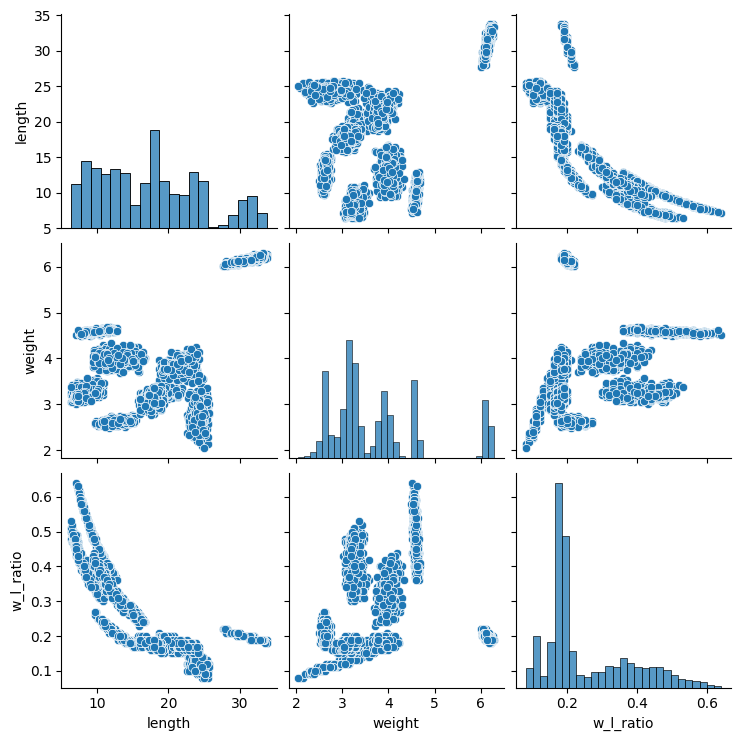

Post-escalado


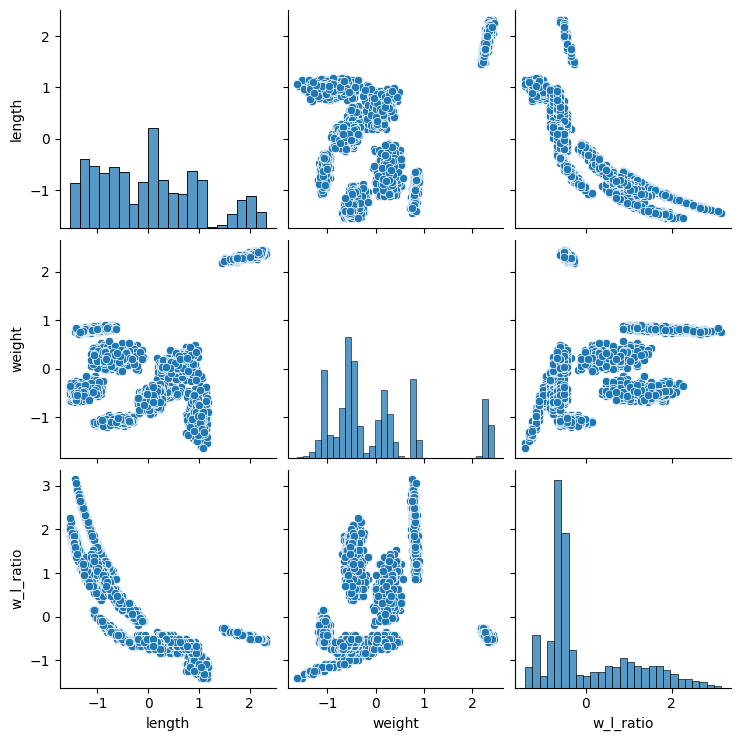

In [28]:
# Mostramos datos sin escalar
print(f"Pre-escalado")
sns.pairplot(dataset_numerical)
plt.show()

# Mostramos datos escalados
print(f"Post-escalado")
sns.pairplot(dataset.drop(columns=["species"]))
plt.show()

 #### **2.1. Clustering jerárquico**

**¿Cómo evaluaremos el modelo?** Para evaluar el modelo vamos a utilizar los siguientes métodos: <br><br>

1) ``Silhouette Distance``: esta métrica evalúa como un modelo ha sido capaz de diferenciar los clusters en función de la cercanía que tiene un dato con su cluster en comparación al siguiente clúster más cercano.
    - Si el punto está más cerca de su cluster que de otro cluster, el modelo ha separado bien los datos (Resultado ~ 1).
    - Si el punto está entre medio de dos clusters, el modelo no está seguro, los clusters se sobreponen (Resultado ~ 0).
    - Si el punto está más cerca de otro cluster que de su propio cluster, el modelo ha separado mal los datos (Resultado ~ -1).

    El resultado del test oscila entre -1 y 1.

<br>

2) ``Davies-Bouldin``: evalúa cómo de compactos son los clústeres ($S_i$ y $S_j$) y como de separados entre ellos están ($M_{ij}$).

    - Resultado ~ 0: los clústeres están bien separados y son compactos (bueno).
    - Cuanto mayor es el valor, peor es la calidad del Clustering, indicando clústeres con datos más dispersos y/o clústeres más cercanos entre sí (malo).
    
    El resultado del test oscila entre 0 y ∞.

<br>

3) ``Dendograma``: gráfico de árbol que muestra las agrupaciones hechas por el modelo.

<br>

4) ``Comparación de labels con predicciones``: los modelos de clustering son <u>no supervisados</u> pero el dataset contiene los labels reales de las categorías. Para saber si se está haciendo una agrupación correcta vamos a comparar los labels del árbol jerárquico con los labels reales.

<br><br>



##### **2.1.1. Primer intento clustering jerárquico**

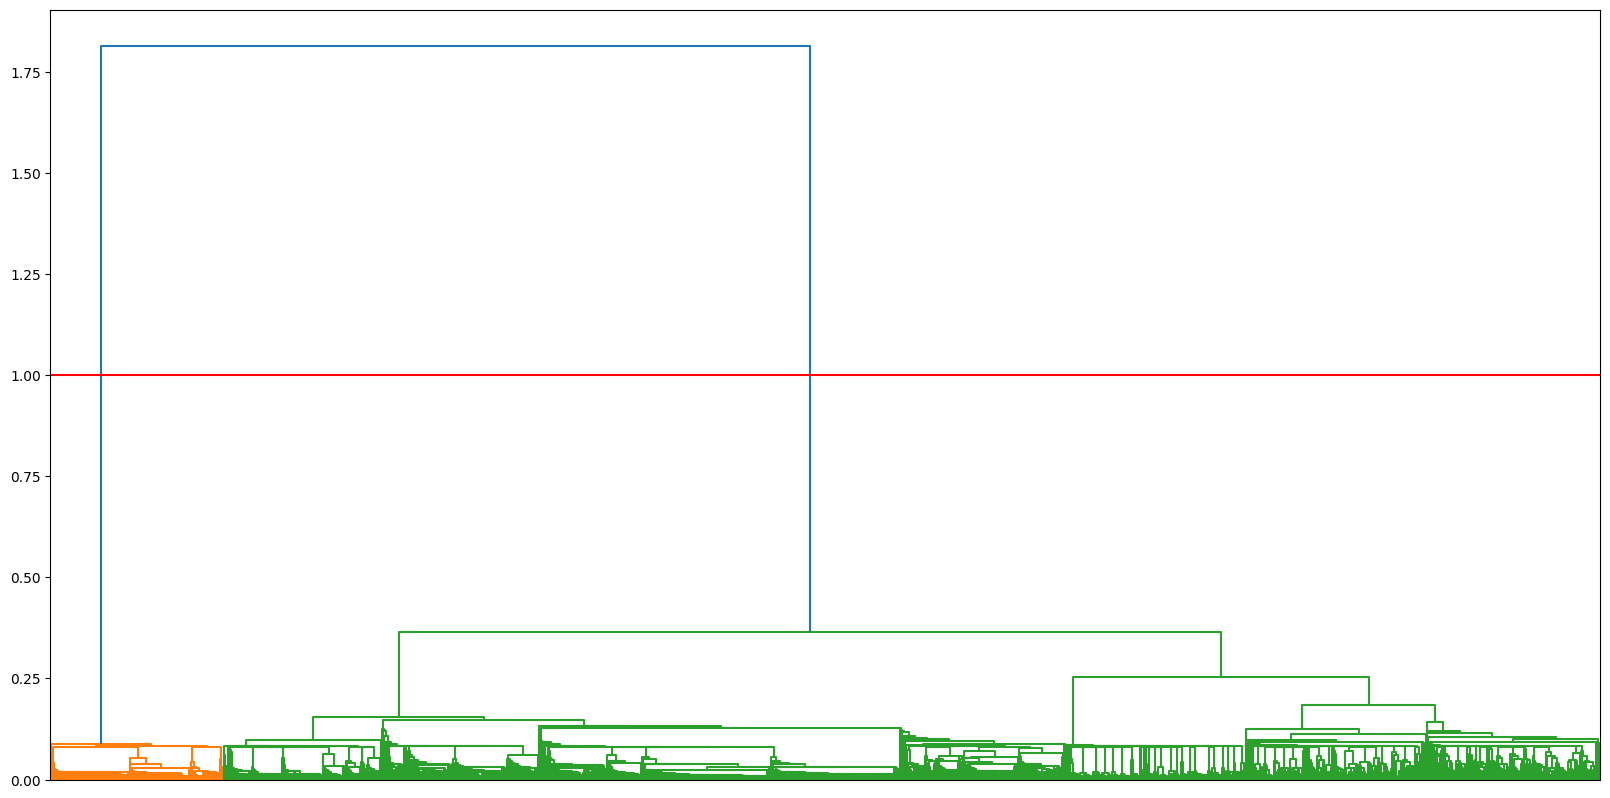

In [29]:
plt.figure(figsize = (20, 10))

# Aplicamos el clustering jerárquico
jerarquic = hierarchy.linkage(dataset_scal)

cluster_distance = 1

# Generamos el grafico
jerarquic_tree = hierarchy.dendrogram(jerarquic, 
                                      color_threshold = cluster_distance, # Indica a partir de de que altura se considera mismo grupo
                                      no_labels = True)
                                    
plt.hlines(cluster_distance, 0, 1000000, color = "r")

plt.show()

In [30]:
# Hacemos clustering jerárquico pero numéricamente, sin dendograma
cluster_labels = fcluster(jerarquic, t = cluster_distance, criterion = "distance")

# Añadimos los labels resultantes en el dataset
dataset["pred"] = cluster_labels
dataset["pred"] = dataset["pred"].astype(object) # Si no será de tipo int32, luego en el pairplot nos dará error

print(f"Clusters únicos: {len(dataset['pred'].unique())}")

Clusters únicos: 2


In [31]:
# Comparamos tabla de comparación de "species" vs "pred"
crosstab = pd.crosstab(dataset['species'], dataset['pred'])

crosstab

pred,1,2
species,,
Anabas testudineus,0,476
Coilia dussumieri,0,415
Otolithoides biauritus,0,468
Otolithoides pama,0,435
Pethia conchonius,0,475
Polynemus paradiseus,0,458
Puntius lateristriga,0,418
Setipinna taty,0,480
Sillaginopsis panijus,455,0


In [32]:
# Aplicamos Silhoutte Score para calcular el rendimiento
sil_score = silhouette_score(dataset_scal, cluster_labels)
print(f"Resultado Silhouette Score: {sil_score}")

Resultado Silhouette Score: 0.5679297452046388


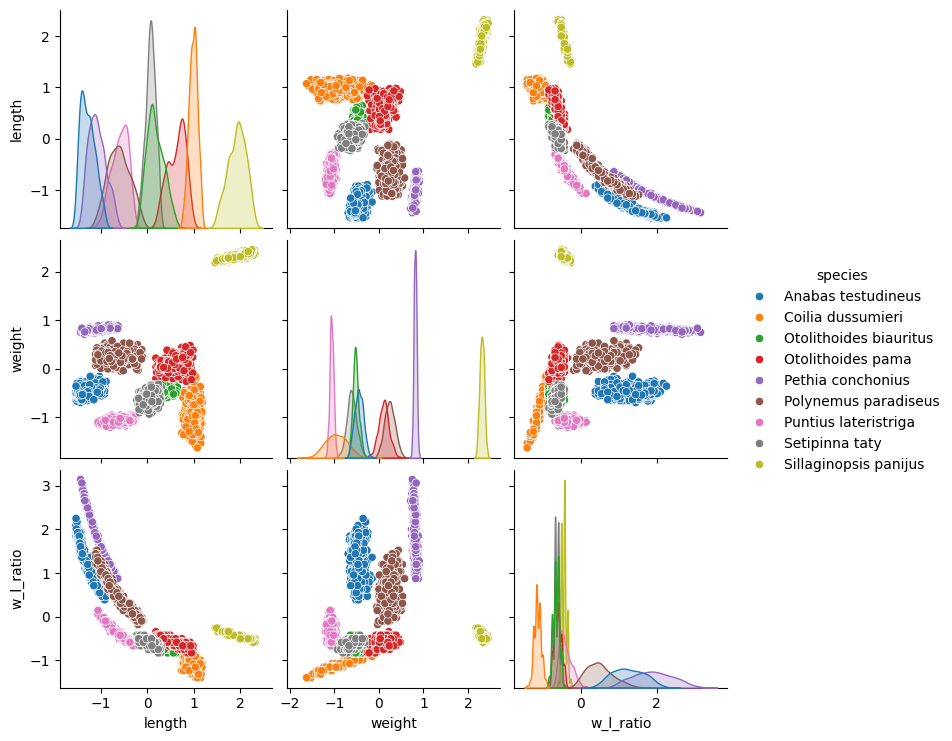

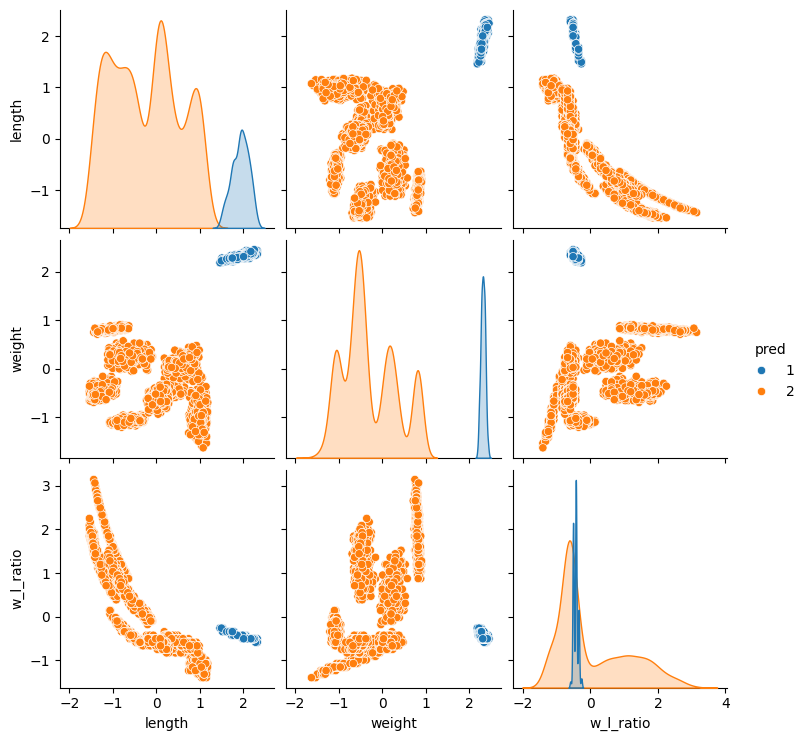

In [33]:
sns.pairplot(data=dataset, hue="species", palette="tab10", 
             vars = ["length", "weight", "w_l_ratio"]) # Internamente la variable "pred" contiene numeros, la estamos ignorando)
plt.show()

sns.pairplot(data=dataset, hue="pred", palette="tab10")
plt.show()

Para facilitar la evaluación del modelo, vamos a crear una función que ejecute todos los pasos anteriores

In [34]:
def evaluate_cluster(df, jerarquic, cluster_distance, show_crosstab: bool = False, show_original_clusters: bool = False, show_new_clusters: bool = True) -> None:
    # Hacemos clustering jerárquico pero numéricamente, sin dendograma
    cluster_labels = fcluster(jerarquic, t = cluster_distance, criterion = "distance")

    # Añadimos los labels resultantes en el dataset
    df["pred"] = cluster_labels
    df["pred"] = df["pred"].astype(object) # Si no será de tipo int32, luego en el pairplot nos dará error

    print(f"Clusters únicos: {len(df['pred'].unique())}")

    # Comparamos tabla de comparación de "species" vs "pred"
    if show_crosstab:
        crosstab = pd.crosstab(df['species'], df['pred'])
        display(crosstab)

    # Aplicamos Silhoutte Score para calcular el rendimiento
    sil_score = silhouette_score(dataset_scal, df['pred'])
    print(f"Resultado Silhouette Score: {sil_score}")

    if show_original_clusters:
        sns.pairplot(data = df, hue = "species", palette = "tab10", 
                vars = ["length", "weight", "w_l_ratio"]) # Internamente la variable "pred" contiene numeros, la estamos ignorando)
        plt.show()

    if show_new_clusters:
        sns.pairplot(data = df, hue = "pred", palette = "tab10")
        plt.show()

##### **2.1.2. Segundo intento clustering jerárquico**

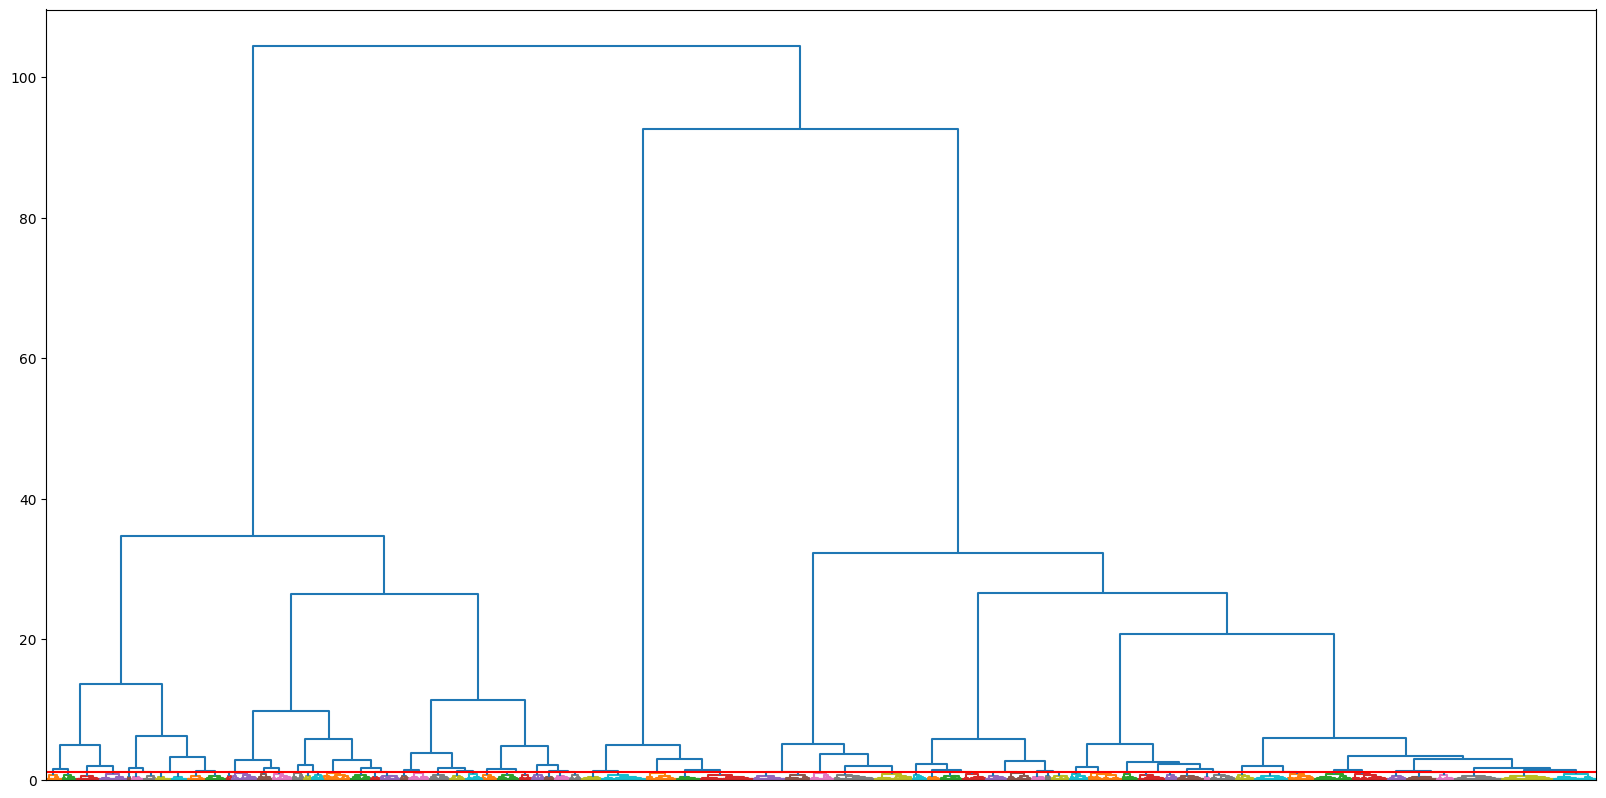

In [35]:
plt.figure(figsize = (20, 10))

# Aplicamos el clustering jerárquico
jerarquic = hierarchy.linkage(dataset_scal, method="ward", metric = "euclidean")

cluster_distance = 1

# Generamos el grafico
jerarquic_tree = hierarchy.dendrogram(jerarquic, 
                                      color_threshold = cluster_distance, # Indica a partir de de que altura se considera mismo grupo
                                      no_labels = True)

plt.hlines(cluster_distance, 0, 1000000, color = "r")

plt.show()

Clusters únicos: 72


pred,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,72
species,,,,,,,,,,,,,,,,,,,,,
Anabas testudineus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Coilia dussumieri,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Otolithoides biauritus,0,0,0,0,0,0,0,0,0,0,...,62,68,28,48,3,10,1,65,73,60
Otolithoides pama,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pethia conchonius,43,38,61,72,11,32,33,40,39,51,...,0,0,0,0,0,0,0,0,0,0
Polynemus paradiseus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Puntius lateristriga,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Setipinna taty,0,0,0,0,0,0,0,0,0,0,...,23,5,72,45,47,69,44,61,64,50
Sillaginopsis panijus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Resultado Silhouette Score: 0.37531179208843113


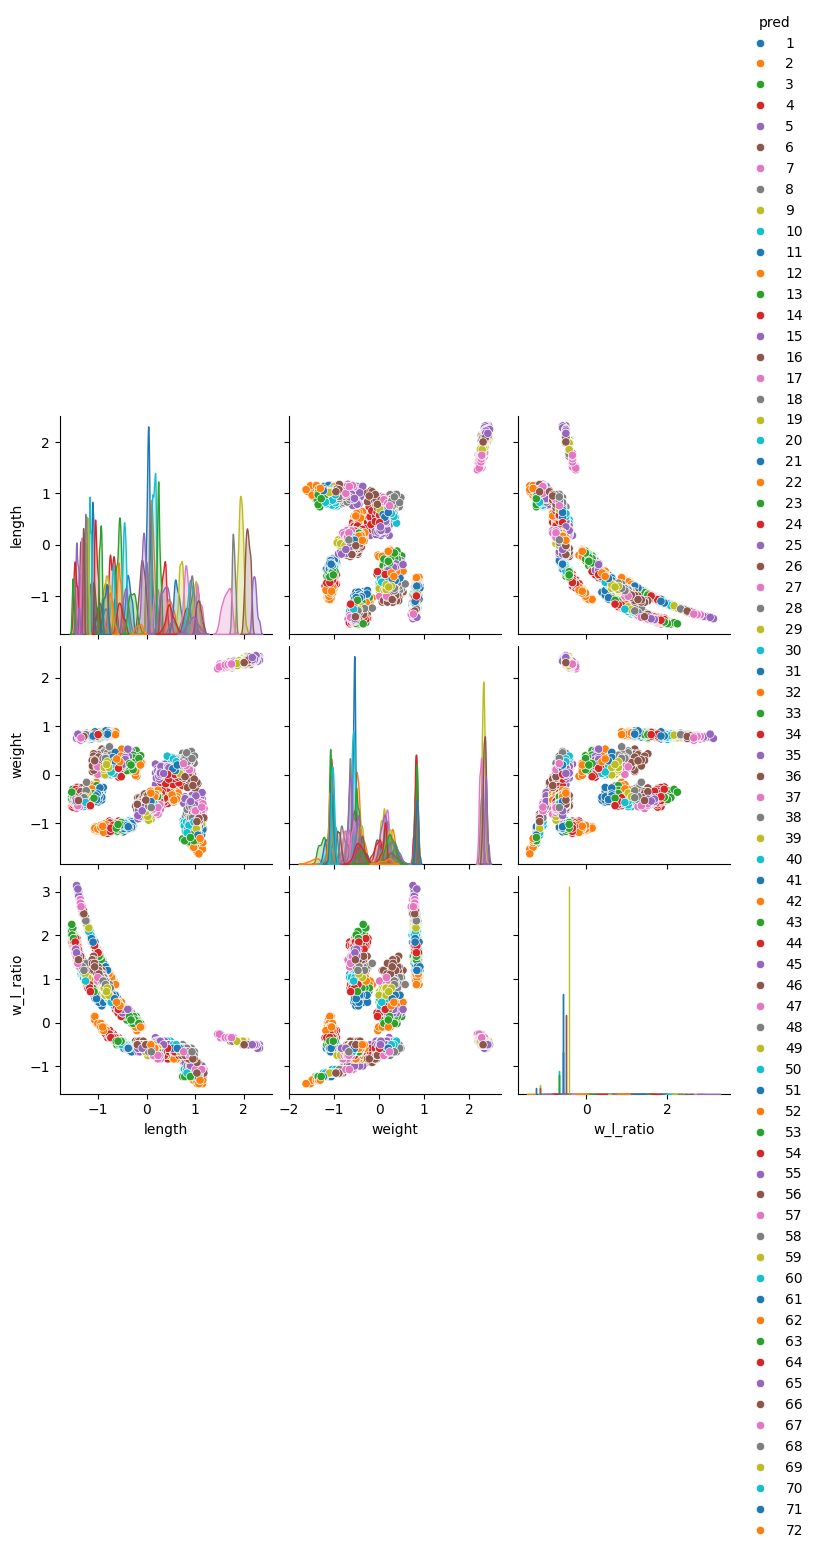

In [36]:
evaluate_cluster(dataset, jerarquic, cluster_distance, show_crosstab = True, show_new_clusters = True)

##### **2.1.3. Tercer intento clustering jerárquico**

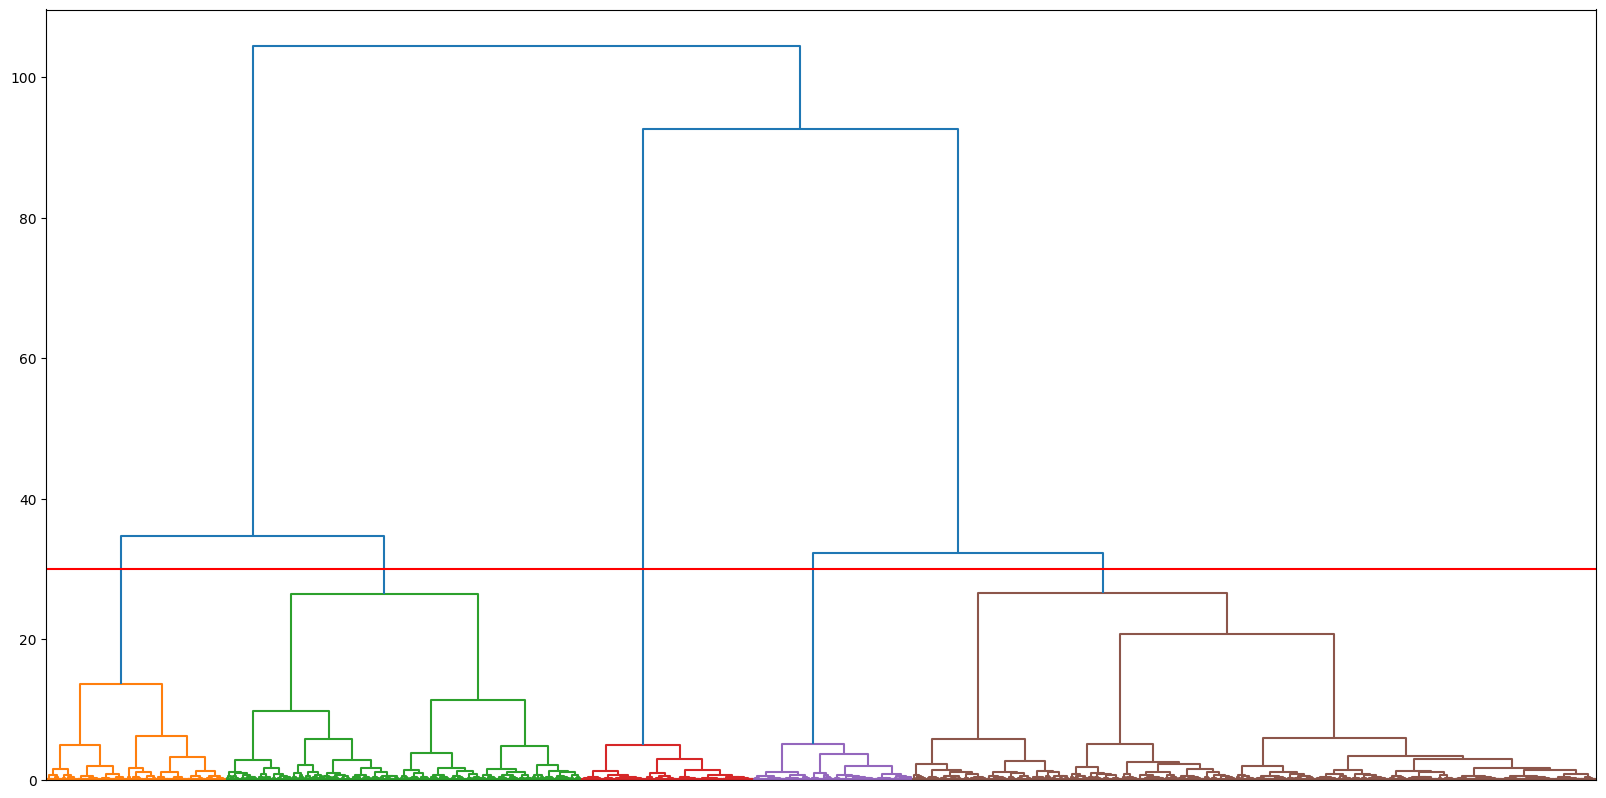

In [37]:
plt.figure(figsize = (20, 10))

# Aplicamos el clustering jerárquico
jerarquic = hierarchy.linkage(dataset_scal, method="ward", metric = "euclidean")

cluster_distance = 30

# Generamos el grafico
jerarquic_tree = hierarchy.dendrogram(jerarquic, 
                    color_threshold = cluster_distance, # Indica a partir de de que altura se considera mismo grupo
                    no_labels = True
                )

plt.hlines(cluster_distance, 0, 1000000, color = "r")

plt.show()

Clusters únicos: 5


pred,1,2,3,4,5
species,,,,,
Anabas testudineus,0,476,0,0,0
Coilia dussumieri,0,0,0,0,415
Otolithoides biauritus,0,0,0,0,468
Otolithoides pama,0,0,0,0,435
Pethia conchonius,475,0,0,0,0
Polynemus paradiseus,0,458,0,0,0
Puntius lateristriga,0,0,0,418,0
Setipinna taty,0,0,0,0,480
Sillaginopsis panijus,0,0,455,0,0


Resultado Silhouette Score: 0.5116304906685719


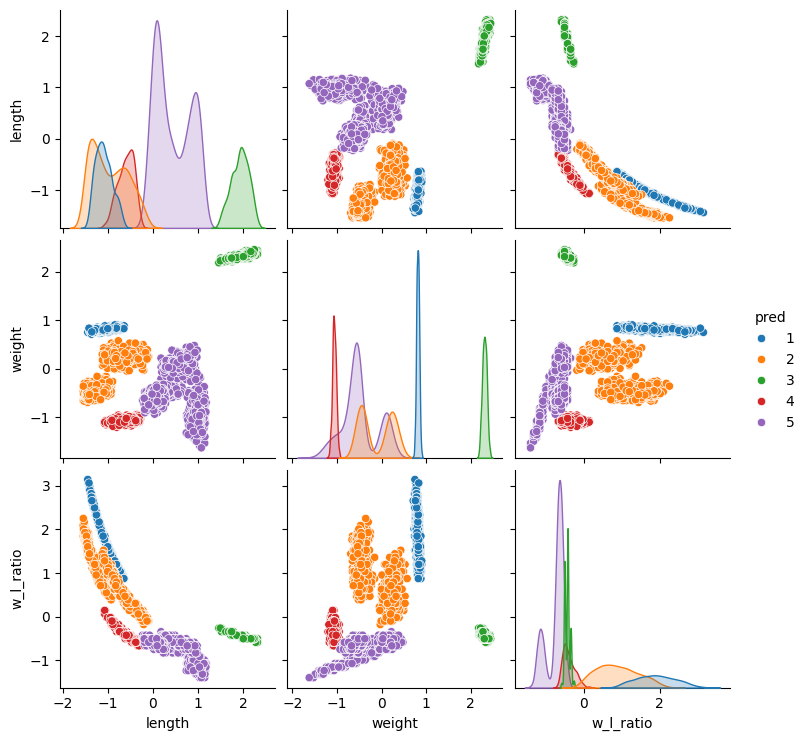

In [38]:
evaluate_cluster(dataset, jerarquic, cluster_distance, show_crosstab = True, show_new_clusters = True)

##### **2.1.4. Cuarto intento clustering jerárquico**

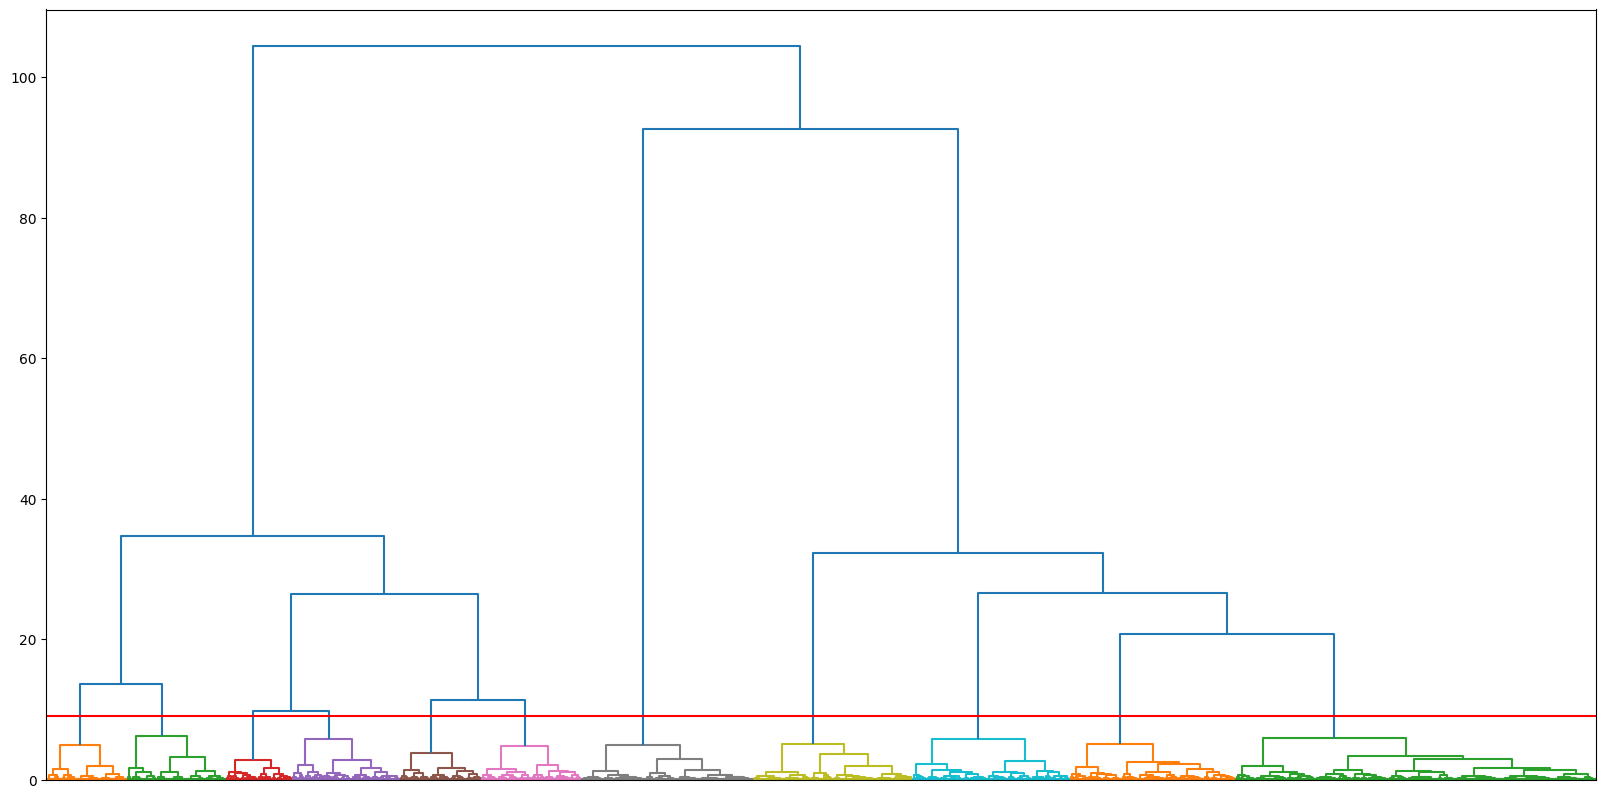

In [39]:
plt.figure(figsize = (20, 10))

# Aplicamos el clustering jerárquico
jerarquic = hierarchy.linkage(dataset_scal, method="ward", metric = "euclidean")

cluster_distance = 9

# Generamos el grafico
jerarquic_tree = hierarchy.dendrogram(jerarquic, 
                    color_threshold = cluster_distance, # Indica a partir de de que altura se considera mismo grupo
                    no_labels = True
                )

plt.hlines(cluster_distance, 0, 1000000, color = "r")

plt.show()

Clusters únicos: 11


pred,1,2,3,4,5,6,7,8,9,10,11
species,,,,,,,,,,,
Anabas testudineus,0,0,0,0,214,262,0,0,0,0,0
Coilia dussumieri,0,0,0,0,0,0,0,0,412,3,0
Otolithoides biauritus,0,0,0,0,0,0,0,0,0,0,468
Otolithoides pama,0,0,0,0,0,0,0,0,0,435,0
Pethia conchonius,214,261,0,0,0,0,0,0,0,0,0
Polynemus paradiseus,0,0,175,283,0,0,0,0,0,0,0
Puntius lateristriga,0,0,0,0,0,0,0,418,0,0,0
Setipinna taty,0,0,0,0,0,0,0,0,0,0,480
Sillaginopsis panijus,0,0,0,0,0,0,455,0,0,0,0


Resultado Silhouette Score: 0.6344109890605106


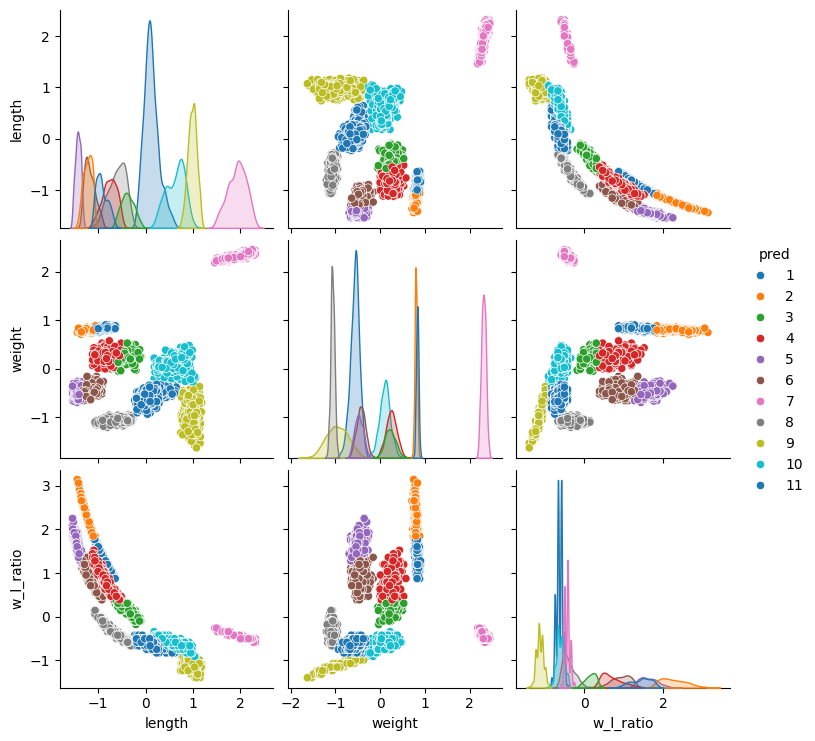

In [40]:
evaluate_cluster(dataset, jerarquic, cluster_distance, show_crosstab = True, show_new_clusters = True)